Bài 1 — Ma trận nhầm lẫn và ba con số cơ bản, trên dữ liệu thật

In [39]:
# thu vien
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
import matplotlib.pyplot as plt

In [40]:
RANDOM_STATE = 42
du_lieu = load_breast_cancer()

X, y = du_lieu.data, du_lieu.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE 
)

In [41]:
# 1 chuẩn hoá bằng StandardScaler (fit trên train, transform cả hai)
scaler = StandardScaler()
X_train_c = scaler.fit_transform(X_train)
X_test_c = scaler.transform(X_test)

In [42]:
# 2 huấn luyện LogisticRegression(max_iter=..., random_state=RANDOM_STATE)
model = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
model.fit(X_train_c,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [43]:
# 3 dự đoán trên X_test, lấy ma trận nhầm lẫn bằng confusion_matrix(y_test, y_pred) tách TN, FP, FN, TP bằng .ravel()
y_pred = model.predict(X_test_c)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(tn, fp, fn, tp)

41 1 1 71


In [44]:
# từ 4 số đó, TỰ TAY tính precision/recall/F1 cho lớp dương (pos_label=1)
p_tay = tp / (tp + fp)
r_tay = tp / (tp + fn)
f1_tay = 2 * p_tay * r_tay / (p_tay + r_tay)

print("precision tự tính :", p_tay)
print("recall tự tính    :", r_tay)
print("f1 tự tính         :", f1_tay)

precision tự tính : 0.9861111111111112
recall tự tính    : 0.9861111111111112
f1 tự tính         : 0.9861111111111112


0.9861111111111112
0.9861111111111112
0.9861111111111112


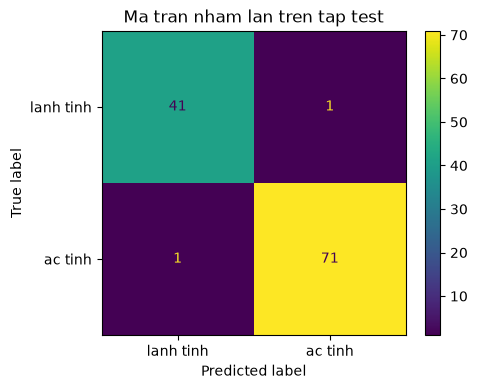

In [50]:
# dự đoán trên X_test, lấy ma trận nhầm lẫn bằng confusion_matrix(y_test, y_pred) tách TN, FP, FN, TP bằng .ravel()
p = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
r = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1_sc = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

print(p)
print(r)
print(f1_sc)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax, display_labels=["lanh tinh", "ac tinh"]
)
ax.set_title("Ma tran nham lan tren tap test")
plt.tight_layout()
plt.show()
plt.close()